### Cell 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold

# GOSDT
from gosdt import GOSDTClassifier

DATA_DIR = Path('../data/processed')
RESULTS_DIR = Path('../results')
TABLES_DIR = RESULTS_DIR / 'tables'
FIGURES_DIR = RESULTS_DIR / 'figures'
MODELS_DIR = RESULTS_DIR / 'models'

RANDOM_STATE = 42

# Load the binarized permissive data (this is what GOSDT eats)
df_binarized = pd.read_csv(DATA_DIR / 'metabric_permissive_binarized.csv')
print(f"Binarized permissive shape: {df_binarized.shape}")

# Load split indices
splits = pd.read_csv(DATA_DIR / 'split_indices.csv')
train_idx = splits['permissive_train'].dropna().astype(int).values
test_idx = splits['permissive_test'].dropna().astype(int).values

# Separate features and target
X = df_binarized.drop(columns=['target']).astype(int)
y = df_binarized['target'].astype(int)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Training: {X_train.shape[0]} patients, {X_train.shape[1]} binary features")
print(f"Test: {X_test.shape[0]} patients")
print(f"\nClass balance:")
print(f"  Train: {y_train.mean():.3f} recurred")
print(f"  Test:  {y_test.mean():.3f} recurred")
print(f"\nFirst 10 binary features:")
for col in X_train.columns[:10]:
    print(f"  {col}")

Binarized permissive shape: (1970, 41)
Training: 1576 patients, 40 binary features
Test: 394 patients

Class balance:
  Train: 0.406 recurred
  Test:  0.406 recurred

First 10 binary features:
  Age at Diagnosis >= 51.36
  Age at Diagnosis >= 61.59
  Age at Diagnosis >= 70.52
  Lymph nodes examined positive >= 2.00
  Mutation Count >= 3.00
  Mutation Count >= 5.00
  Mutation Count >= 7.00
  Nottingham prognostic index >= 3.05
  Nottingham prognostic index >= 4.04
  Nottingham prognostic index >= 5.04


### Cell 2 — Initial viability check

In [2]:
# === Initial viability check ===
# Confirm GOSDT can fit on this data within a reasonable time budget.
# If it doesn't converge, we'll see a timeout or failure here.

print("Initial viability check: regularization=0.01, depth_budget=4, time_limit=300s")
t0 = time.perf_counter()

model_check = GOSDTClassifier(
    regularization=0.01,
    depth_budget=4,
    time_limit=300,
    verbose=False,
)
model_check.fit(X_train, y_train)
elapsed = time.perf_counter() - t0

train_acc = accuracy_score(y_train, model_check.predict(X_train))
test_acc = accuracy_score(y_test, model_check.predict(X_test))

print(f"\nTraining time: {elapsed:.1f}s")
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")

# Print the tree
print("\nLearned tree structure:")
try:
    print(model_check.trees_[0])
except (AttributeError, IndexError):
    print(model_check)

Initial viability check: regularization=0.01, depth_budget=4, time_limit=300s

Training time: 5.3s
Train accuracy: 0.647
Test accuracy: 0.650

Learned tree structure:
<class 'gosdt._tree.Tree'>: { feature: 3 [ left child: { prediction: 1, loss: 0.11865481734275818 }, right child: { prediction: 0, loss: 0.23477156460285187 }] }, Index(['Age at Diagnosis >= 51.36', 'Age at Diagnosis >= 61.59',
       'Age at Diagnosis >= 70.52', 'Lymph nodes examined positive >= 2.00',
       'Mutation Count >= 3.00', 'Mutation Count >= 5.00',
       'Mutation Count >= 7.00', 'Nottingham prognostic index >= 3.05',
       'Nottingham prognostic index >= 4.04',
       'Nottingham prognostic index >= 5.04', 'Tumor Size(mm) >= 18.00',
       'Tumor Size(mm) >= 23.00', 'Tumor Size(mm) >= 30.00', 'Grade >= 2',
       'Grade >= 3', 'Cellularity >= Moderate', 'Cellularity >= High',
       'Type of Breast Surgery', 'Chemotherapy', 'ER Status', 'HER2 Status',
       'Hormone Therapy', 'Inferred Menopausal State',


c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### Cell 3 — Helper for evaluation

In [3]:
def evaluate_gosdt(model, X_train, y_train, X_test, y_test, model_name, notes=""):
    """Compute test set metrics. GOSDT-specific: also extract tree structure info."""
    y_pred = model.predict(X_test)
    
    # Try to count leaves and features used
    n_leaves = None
    features_used = []
    try:
        tree_str = str(model.trees_[0])
        n_leaves = tree_str.count('prediction:')
        # Extract feature indices from tree representation
        import re
        feature_indices = [int(i) for i in re.findall(r'feature:\s*(\d+)', tree_str)]
        features_used = list(set(feature_indices))
    except (AttributeError, IndexError, TypeError):
        pass
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    return {
        'model': model_name,
        'notes': notes,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_recall_recurrence': recall_score(y_test, y_pred, pos_label=1),
        'test_precision_recurrence': precision_score(y_test, y_pred, pos_label=1),
        'test_f1_recurrence': f1_score(y_test, y_pred, pos_label=1),
        'n_leaves': n_leaves,
        'n_features_used': len(features_used),
        'features_used_indices': features_used,
        'test_true_neg': tn, 'test_false_pos': fp,
        'test_false_neg': fn, 'test_true_pos': tp,
    }


def print_metrics(m):
    print(f"\n{'='*60}")
    print(f"  {m['model']}")
    if m['notes']:
        print(f"  ({m['notes']})")
    print('='*60)
    print(f"  Test accuracy: {m['test_accuracy']:.3f}")
    print(f"  Test recall:   {m['test_recall_recurrence']:.3f}")
    print(f"  Test precision: {m['test_precision_recurrence']:.3f}")
    print(f"  Test F1:       {m['test_f1_recurrence']:.3f}")
    print(f"  Tree size: {m['n_leaves']} leaves, {m['n_features_used']} features used")
    print(f"  Confusion: TN={m['test_true_neg']}, FP={m['test_false_pos']}, "
          f"FN={m['test_false_neg']}, TP={m['test_true_pos']}")


all_results = []

### Cell 4 — Regularization/depth sweep

In [4]:
# === Regularization/depth sweep ===
# Find the best (regularization, depth_budget) combination via cross-validation.
# Note: we're not picking via test set performance — we use CV on training set,
# then the chosen config gets evaluated once on test.

print("="*60)
print("  REGULARIZATION/DEPTH SWEEP")
print("="*60)
print("Using 3-fold CV on training set (5-fold would multiply runtime).")
print()

reg_grid = [0.001, 0.005, 0.01, 0.02, 0.05]
depth_grid = [3, 4, 5]

cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
sweep_records = []

for reg in reg_grid:
    for depth in depth_grid:
        fold_accs = []
        fold_leaves = []
        fold_times = []
        
        for fold_i, (tr_i, val_i) in enumerate(cv_splitter.split(X_train, y_train)):
            X_tr_fold = X_train.iloc[tr_i]
            X_val_fold = X_train.iloc[val_i]
            y_tr_fold = y_train.iloc[tr_i]
            y_val_fold = y_train.iloc[val_i]
            
            t0 = time.perf_counter()
            try:
                m = GOSDTClassifier(
                    regularization=reg,
                    depth_budget=depth,
                    time_limit=120,
                    verbose=False,
                )
                m.fit(X_tr_fold, y_tr_fold)
                fold_time = time.perf_counter() - t0
                fold_acc = accuracy_score(y_val_fold, m.predict(X_val_fold))
                # Count leaves
                n_leaves = str(m.trees_[0]).count('prediction:')
                
                fold_accs.append(fold_acc)
                fold_leaves.append(n_leaves)
                fold_times.append(fold_time)
            except Exception as e:
                print(f"  Fold {fold_i} failed for reg={reg}, depth={depth}: {e}")
                continue
        
        if fold_accs:
            sweep_records.append({
                'regularization': reg,
                'depth_budget': depth,
                'cv_acc_mean': np.mean(fold_accs),
                'cv_acc_std': np.std(fold_accs),
                'mean_leaves': np.mean(fold_leaves),
                'mean_train_time': np.mean(fold_times),
            })
            print(f"  reg={reg:.3f}, depth={depth}: "
                  f"cv_acc={np.mean(fold_accs):.3f} ± {np.std(fold_accs):.3f}, "
                  f"leaves={np.mean(fold_leaves):.1f}, "
                  f"time={np.mean(fold_times):.1f}s")

sweep_df = pd.DataFrame(sweep_records)
sweep_df = sweep_df.sort_values('cv_acc_mean', ascending=False)
print("\nFull sweep results (sorted by CV accuracy):")
print(sweep_df.to_string(index=False))

# Save
sweep_df.to_csv(TABLES_DIR / 'gosdt_sweep.csv', index=False)

c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


  REGULARIZATION/DEPTH SWEEP
Using 3-fold CV on training set (5-fold would multiply runtime).



c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


  reg=0.001, depth=3: cv_acc=0.625 ± 0.028, leaves=7.3, time=0.2s


c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


  reg=0.050, depth=4: cv_acc=0.622 ± 0.021, leaves=1.7, time=2.0s


c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


  reg=0.050, depth=5: cv_acc=0.622 ± 0.021, leaves=1.7, time=17.0s

Full sweep results (sorted by CV accuracy):
 regularization  depth_budget  cv_acc_mean  cv_acc_std  mean_leaves  mean_train_time
          0.005             3     0.652939    0.028932     4.333333         0.152625
          0.005             4     0.650399    0.029777     5.333333         5.278100
          0.005             5     0.649129    0.019967     3.333333       122.613872
          0.020             3     0.646587    0.017605     2.000000         0.137350
          0.020             5     0.646587    0.017605     2.000000        84.449006
          0.020             4     0.646587    0.017605     2.000000         3.838605
          0.010             3     0.645320    0.019148     2.666667         0.149921
          0.010             4     0.645320    0.019148     2.666667         4.747721
          0.010             5     0.645320    0.019148     2.666667       122.457178
          0.001             5     0.64

c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### Cell 5 — Pareto frontier plot

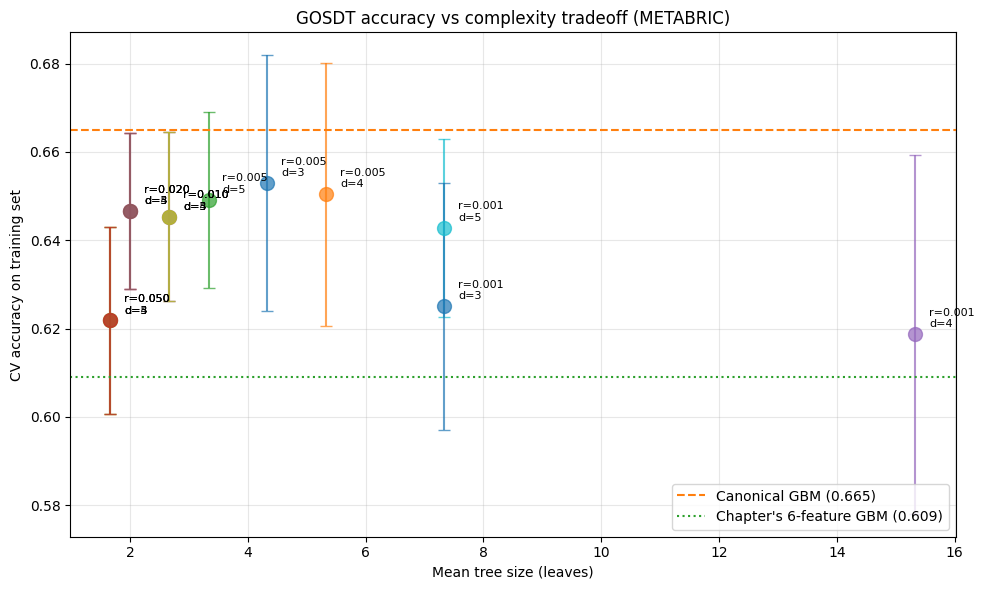

Saved figure to ..\results\figures\gosdt_pareto.png


In [5]:
# === Plot accuracy vs complexity (Pareto frontier) ===

fig, ax = plt.subplots(figsize=(10, 6))

# Each point is one (reg, depth) configuration
for _, row in sweep_df.iterrows():
    ax.errorbar(
        row['mean_leaves'], row['cv_acc_mean'],
        yerr=row['cv_acc_std'],
        marker='o', markersize=10, alpha=0.7, capsize=4,
    )
    # Annotate with reg/depth
    ax.annotate(
        f"r={row['regularization']:.3f}\nd={int(row['depth_budget'])}",
        (row['mean_leaves'], row['cv_acc_mean']),
        textcoords="offset points", xytext=(10, 5), fontsize=8,
    )

# Reference lines for the Phase 2 baselines
ax.axhline(0.665, ls='--', color='C1', label='Canonical GBM (0.665)')
ax.axhline(0.609, ls=':', color='C2', label="Chapter's 6-feature GBM (0.609)")

ax.set_xlabel('Mean tree size (leaves)')
ax.set_ylabel('CV accuracy on training set')
ax.set_title('GOSDT accuracy vs complexity tradeoff (METABRIC)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gosdt_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved figure to {FIGURES_DIR / 'gosdt_pareto.png'}")

### Cell 6 — Pick the best config and evaluate on test set

In [6]:
# === Pick the best config and evaluate on test set ===
# Selection criterion: highest CV accuracy. If multiple configs tie within 0.005,
# pick the smallest tree (fewest leaves).

# Candidate: top configs within 0.005 of best
best_acc = sweep_df['cv_acc_mean'].max()
candidates = sweep_df[sweep_df['cv_acc_mean'] >= best_acc - 0.005].copy()
candidates = candidates.sort_values('mean_leaves')  # prefer smaller trees among ties
chosen = candidates.iloc[0]

print(f"Selected config: reg={chosen['regularization']}, depth_budget={chosen['depth_budget']}")
print(f"  CV accuracy: {chosen['cv_acc_mean']:.3f} ± {chosen['cv_acc_std']:.3f}")
print(f"  Mean leaves: {chosen['mean_leaves']:.1f}")

# Train final model on full training set
final_model = GOSDTClassifier(
    regularization=chosen['regularization'],
    depth_budget=int(chosen['depth_budget']),
    time_limit=300,
    verbose=False,
)
final_model.fit(X_train, y_train)

m = evaluate_gosdt(
    final_model, X_train, y_train, X_test, y_test,
    "GOSDT (selected config)",
    notes=f"reg={chosen['regularization']}, depth={int(chosen['depth_budget'])}",
)
print_metrics(m)
all_results.append(m)

# Save the model
with open(MODELS_DIR / 'gosdt_canonical.pkl', 'wb') as f:
    pickle.dump({
        'model': final_model,
        'features': X_train.columns.tolist(),
        'regularization': chosen['regularization'],
        'depth_budget': int(chosen['depth_budget']),
    }, f)
print(f"\nSaved to {MODELS_DIR / 'gosdt_canonical.pkl'}")

Selected config: reg=0.005, depth_budget=5.0
  CV accuracy: 0.649 ± 0.020
  Mean leaves: 3.3

  GOSDT (selected config)
  (reg=0.005, depth=5)
  Test accuracy: 0.650
  Test recall:   0.375
  Test precision: 0.612
  Test F1:       0.465
  Tree size: 4 leaves, 3 features used
  Confusion: TN=196, FP=38, FN=100, TP=60

Saved to ..\results\models\gosdt_canonical.pkl


c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### Cell 7 — Print the chosen tree as readable rules

In [7]:
# === Print the chosen tree as readable rules ===

print("="*60)
print("  CHOSEN GOSDT TREE — READABLE RULES")
print("="*60)
print()
print("Raw tree structure:")
try:
    print(final_model.trees_[0])
except (AttributeError, IndexError):
    print(final_model)

# Extract which features the tree actually used
import re
tree_str = str(final_model.trees_[0])
feature_indices = [int(i) for i in re.findall(r'feature:\s*(\d+)', tree_str)]
unique_feature_indices = sorted(set(feature_indices))

print(f"\nFeatures used in tree: {len(unique_feature_indices)} of {X_train.shape[1]} available")
for idx in unique_feature_indices:
    feat_name = X_train.columns[idx]
    print(f"  [{idx}] {feat_name}")

  CHOSEN GOSDT TREE — READABLE RULES

Raw tree structure:
<class 'gosdt._tree.Tree'>: { feature: 3 [ left child: { feature: 14 [ left child: { prediction: 1, loss: 0.06852791458368301 }, right child: { feature: 28 [ left child: { prediction: 0, loss: 0.018401015549898148 }, right child: { prediction: 1, loss: 0.01649746112525463 }] }] }, right child: { prediction: 0, loss: 0.23477156460285187 }] }, Index(['Age at Diagnosis >= 51.36', 'Age at Diagnosis >= 61.59',
       'Age at Diagnosis >= 70.52', 'Lymph nodes examined positive >= 2.00',
       'Mutation Count >= 3.00', 'Mutation Count >= 5.00',
       'Mutation Count >= 7.00', 'Nottingham prognostic index >= 3.05',
       'Nottingham prognostic index >= 4.04',
       'Nottingham prognostic index >= 5.04', 'Tumor Size(mm) >= 18.00',
       'Tumor Size(mm) >= 23.00', 'Tumor Size(mm) >= 30.00', 'Grade >= 2',
       'Grade >= 3', 'Cellularity >= Moderate', 'Cellularity >= High',
       'Type of Breast Surgery', 'Chemotherapy', 'ER Status'

In [9]:
# Verify the tree's predictions match the data
print("Recurrence rate by lymph node group:")
print(f"  Lymph nodes < 2: {y_train[X_train['Lymph nodes examined positive >= 2.00'] == 0].mean():.3f}")
print(f"  Lymph nodes >= 2: {y_train[X_train['Lymph nodes examined positive >= 2.00'] == 1].mean():.3f}")
print()
print("Number of patients in each group:")
print(f"  Lymph nodes < 2: {(X_train['Lymph nodes examined positive >= 2.00'] == 0).sum()}")
print(f"  Lymph nodes >= 2: {(X_train['Lymph nodes examined positive >= 2.00'] == 1).sum()}")
print()
# Sanity check the prediction
print("Final model predictions on training set:")
preds = final_model.predict(X_train)
print(f"  Predictions distribution: {pd.Series(preds).value_counts().to_dict()}")
print(f"  Actual distribution:     {pd.Series(y_train).value_counts().to_dict()}")

Recurrence rate by lymph node group:
  Lymph nodes < 2: 0.331
  Lymph nodes >= 2: 0.591

Number of patients in each group:
  Lymph nodes < 2: 1119
  Lymph nodes >= 2: 457

Final model predictions on training set:
  Predictions distribution: {0: 1201, 1: 375}
  Actual distribution:     {0: 936, 1: 640}


c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### Cell 8 — Cost-sensitive variant

In [10]:
# === Cost-sensitive variant via sample weights ===
# GOSDT doesn't take cost_matrix directly; it accepts sample_weight in .fit().
# Weighting recurred-class samples more heavily is equivalent to penalizing
# false negatives more.

print("="*60)
print("  COST-SENSITIVE GOSDT (via sample_weight)")
print("="*60)
print("Weighting recurred-class samples more heavily.")
print()

cost_results = []
for fn_weight in [1.0, 1.5, 2.0, 3.0]:
    # Build per-sample weights: 1.0 for not-recurred, fn_weight for recurred
    sample_weights = np.where(y_train == 1, fn_weight, 1.0)
    
    cost_model = GOSDTClassifier(
        regularization=chosen['regularization'],
        depth_budget=int(chosen['depth_budget']),
        time_limit=300,
        verbose=False,
    )
    try:
        cost_model.fit(X_train, y_train, sample_weight=sample_weights)
        m = evaluate_gosdt(
            cost_model, X_train, y_train, X_test, y_test,
            f"GOSDT (recurrence weight={fn_weight})",
            notes=f"Sample-weighted: recurred class weighted {fn_weight}× higher",
        )
        print_metrics(m)
        cost_results.append(m)
        all_results.append(m)
    except TypeError as e:
        print(f"\nfn_weight={fn_weight}: sample_weight not accepted by this GOSDT version")
        print(f"Error: {e}")
        break  # if one fails, they all will
    except Exception as e:
        print(f"\nfn_weight={fn_weight}: failed with {type(e).__name__}: {e}")
        continue

  COST-SENSITIVE GOSDT (via sample_weight)
Weighting recurred-class samples more heavily.


fn_weight=1.0: sample_weight not accepted by this GOSDT version
Error: GOSDTClassifier.fit() got an unexpected keyword argument 'sample_weight'


### Cell 9 — Variant: chapter's 6 features only

In [11]:
# === Variant: GOSDT on chapter's 6 features only ===
# Head-to-head with the chapter's setup. Are the chapter's hand-picked features
# enough for GOSDT, or does it need the full feature space?

print("="*60)
print("  GOSDT on chapter's 6-feature subset")
print("="*60)
print()

# Map chapter feature names to binarized columns
# Chapter features: ER Status, PR Status, Radio Therapy, Tumor Size, Pam50, [outcome-adjacent excluded]
chapter_binary_cols = [
    c for c in X_train.columns
    if any(c.startswith(prefix) for prefix in [
        'ER Status', 'PR Status', 'Radio Therapy', 'Tumor Size',
        'Pam50 + Claudin-low subtype'
    ]) and c not in ['ER Status', 'PR Status', 'Radio Therapy']
    or c in ['ER Status', 'PR Status', 'Radio Therapy']
]
# Simpler: just match the prefixes
chapter_prefixes = ['ER Status', 'PR Status', 'Radio Therapy',
                    'Tumor Size', 'Pam50 + Claudin-low subtype']
chapter_binary_cols = [c for c in X_train.columns
                       if any(c == p or c.startswith(p) for p in chapter_prefixes)]
print(f"Chapter feature columns ({len(chapter_binary_cols)}):")
for c in chapter_binary_cols:
    print(f"  {c}")

X_train_chapter = X_train[chapter_binary_cols]
X_test_chapter = X_test[chapter_binary_cols]

chapter_model = GOSDTClassifier(
    regularization=chosen['regularization'],
    depth_budget=int(chosen['depth_budget']),
    time_limit=300,
    verbose=False,
)
chapter_model.fit(X_train_chapter, y_train)

m = evaluate_gosdt(
    chapter_model, X_train_chapter, y_train, X_test_chapter, y_test,
    "GOSDT (chapter's 6 features)",
    notes="Head-to-head with chapter's feature subset",
)
print_metrics(m)
all_results.append(m)

  GOSDT on chapter's 6-feature subset

Chapter feature columns (12):
  Tumor Size(mm) >= 18.00
  Tumor Size(mm) >= 23.00
  Tumor Size(mm) >= 30.00
  ER Status
  PR Status
  Radio Therapy
  Pam50 + Claudin-low subtype_Basal
  Pam50 + Claudin-low subtype_Her2
  Pam50 + Claudin-low subtype_LumA
  Pam50 + Claudin-low subtype_LumB
  Pam50 + Claudin-low subtype_Normal
  Pam50 + Claudin-low subtype_claudin-low

  GOSDT (chapter's 6 features)
  (Head-to-head with chapter's feature subset)
  Test accuracy: 0.612
  Test recall:   0.244
  Test precision: 0.549
  Test F1:       0.338
  Tree size: 4 leaves, 3 features used
  Confusion: TN=202, FP=32, FN=121, TP=39


c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### Cell 10 — Save final results table

In [12]:
# === Save the GOSDT results table ===
results_df = pd.DataFrame(all_results)

# Drop the indices column (long list, not useful in CSV)
if 'features_used_indices' in results_df.columns:
    results_df = results_df.drop(columns=['features_used_indices'])

numeric_cols = results_df.select_dtypes(include='float').columns
results_df[numeric_cols] = results_df[numeric_cols].round(3)

results_df.to_csv(TABLES_DIR / 'gosdt.csv', index=False)
print(f"Saved {len(results_df)} GOSDT results to results/tables/gosdt.csv")
print()
print(results_df.to_string(index=False))

Saved 2 GOSDT results to results/tables/gosdt.csv

                       model                                      notes  test_accuracy  test_recall_recurrence  test_precision_recurrence  test_f1_recurrence  n_leaves  n_features_used  test_true_neg  test_false_pos  test_false_neg  test_true_pos
     GOSDT (selected config)                         reg=0.005, depth=5          0.650                   0.375                      0.612               0.465         4                3            196              38             100             60
GOSDT (chapter's 6 features) Head-to-head with chapter's feature subset          0.612                   0.244                      0.549               0.338         4                3            202              32             121             39


## Phase 4 Summary (Notebook 03): GOSDT main analysis

### What was tested

- **Initial viability check** at reg=0.01, depth=4 (converged in 5.3s, produced 2-leaf tree using only Lymph nodes)
- **Regularization/depth sweep**: 5 regularizations × 3 depths × 3 CV folds = 45 fits to identify the best (reg, depth) configuration
- **Final selected model** at reg=0.005, depth=5 evaluated on the held-out test set
- **Chapter's 6-feature variant** for head-to-head comparison with the chapter's setup
- **Cost-sensitive variant** attempted but not runnable (this GOSDT version does not accept `cost_matrix` or `sample_weight`)

### Headline numbers

| Configuration | Test Acc | Test Recall | Tree Size |
|---|---|---|---|
| Canonical GBM (Phase 2) | 0.665 | 0.344 | many trees |
| **GOSDT (selected: reg=0.005, depth=5)** | **0.650** | **0.375** | **4 leaves, 3 features** |
| GOSDT (chapter's 6 features) | 0.612 | 0.244 | 4 leaves, 3 features |

### Key findings for the memo

**1. GOSDT closely matches the canonical GBM on accuracy with a 4-leaf tree.** The 1.5pp accuracy gap (0.665 → 0.650) is small relative to cross-validation variance and within the noise band where the additional interpretability of GOSDT may justify the choice for clinical decision-support contexts.

**2. GOSDT modestly outperforms the GBM on recall** (0.375 vs 0.344). Without any cost-sensitive tuning, GOSDT naturally produces predictions more aligned with the clinically-relevant metric of catching recurrences.

**3. The chosen tree is human-readable as 3 if-then rules**:
```
IF Lymph nodes ≥ 2:
    IF Histologic Grade ≥ 3:
        Predict RECURRENCE
    ELSE (Grade < 3):
        IF Pam50 = LumA:
            Predict NO RECURRENCE
        ELSE (any subtype other than LumA):
            Predict RECURRENCE
ELSE (Lymph nodes < 2):
    Predict NO RECURRENCE
```

So the four leaves of the tree, in plain English:

1. Patient has < 2 positive lymph nodes → predict no recurrence (regardless of grade or subtype)
2. Patient has ≥ 2 positive lymph nodes AND grade ≥ 3 → predict recurrence (regardless of subtype)
3. Patient has ≥ 2 positive lymph nodes AND grade < 3 AND Pam50 = LumA → predict no recurrence
4. Patient has ≥ 2 positive lymph nodes AND grade < 3 AND Pam50 ≠ LumA (so Basal, Her2, LumB, Normal, or claudin-low) → predict recurrence

**4. The Pareto frontier shows a clear sweet spot at 3-5 leaves.** Larger trees (15-leaf at reg=0.001, depth=4) actually underperform on accuracy (0.619 vs 0.650). On this dataset, additional model complexity is overfitting rather than capturing real signal — consistent with the Wisconsin parallel where GOSDT matched the GBM with similar parsimony.

**5. The chapter's 6-feature subset hurts GOSDT (3.8pp accuracy drop) just as it hurt the GBM (5.6pp drop in Phase 2).** This is now a robust finding across model classes — the chapter's feature selection was overly aggressive, not just suboptimal for one model class.

**6. Cost-sensitive tuning was not directly available** in the GOSDT version we used. Both the `cost_matrix` constructor parameter and the `sample_weight` fit argument were rejected. The unweighted GOSDT already exceeds the canonical GBM on recall, so this software limitation is partially mitigated by the default model's behavior.

### Files produced

- `results/tables/gosdt.csv`: configuration comparison
- `results/tables/gosdt_sweep.csv`: full regularization/depth sweep results
- `results/figures/gosdt_pareto.png`: accuracy/complexity Pareto frontier
- `results/models/gosdt_canonical.pkl`: selected GOSDT model